**PRACTICA DE MINERIA PREDICTIVA - CALIFORNIA HOUSING PRICES**

# Informacion del dataset:

California Housing Prices
Median house prices for California districts derived from the 1990 census.

1. longitude: A measure of how far west a house is; a higher value is farther west

2. latitude: A measure of how far north a house is; a higher value is farther north

3. housingMedianAge: Median age of a house within a block; a lower number is a newer building

4. totalRooms: Total number of rooms within a block

5. totalBedrooms: Total number of bedrooms within a block

6. population: Total number of people residing within a block

7. households: Total number of households, a group of people residing within a home unit, for a block

8. medianIncome: Median income for households within a block of houses (measured in tens of thousands of US Dollars)

9. medianHouseValue: Median house value for households within a block (measured in US Dollars)

10. oceanProximity: Location of the house w.r.t ocean/sea

# 1. Preparacion de los datos:



In [1]:
import pandas as pd
import numpy as np  # matrices y vectores
import matplotlib.pyplot as plt #gráfica

Este código importa `pandas` para datos, `numpy` para cálculos y
`matplotlib.pyplot` para gráficos.

In [2]:
data = pd.read_csv('housing.csv')
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Carga el archivo `housing.csv` en un DataFrame llamado `data` y muestra las primeras 5 filas para una vista rápida de los datos.

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


`data.info()` da un resumen de las columnas: cuántos datos no nulos hay y el tipo de dato. Sirve para ver si faltan datos o si los tipos son correctos.

In [4]:
data['ocean_proximity']=data['ocean_proximity'].astype('category')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           20640 non-null  float64 
 1   latitude            20640 non-null  float64 
 2   housing_median_age  20640 non-null  float64 
 3   total_rooms         20640 non-null  float64 
 4   total_bedrooms      20433 non-null  float64 
 5   population          20640 non-null  float64 
 6   households          20640 non-null  float64 
 7   median_income       20640 non-null  float64 
 8   median_house_value  20640 non-null  float64 
 9   ocean_proximity     20640 non-null  category
dtypes: category(1), float64(9)
memory usage: 1.4 MB


Convierte la columna `ocean_proximity` a tipo categórico para optimizarla. `data.info()` confirma el cambio de tipo.

# **1.2. Eliminar variables irrelevantes y redundantes**

No existen formulas que demuestren la redundancia entre las variables.

# **1.3. Descripción estadística**

In [5]:
!pip install ydata-profiling

from ydata_profiling import ProfileReport

profile_data=ProfileReport(data, minimal=True)
profile_data

profile_data.to_file(output_file="output.html")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 78.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 54.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 8.7 MB/s eta 0:00:00


/tmp/ipykernel_1005/1825539578.py:3: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 10/10 [00:00<00:00, 75.88it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Instala ydata-profiling y crea un informe detallado de los datos (guardado como output.html). Este informe ayuda a entender la calidad y características de los datos, como valores faltantes o atípicos.

El perfilado de los 20.640 registros y 10 variables muestra un conjunto en buen estado general: solo el 0,1% de las celdas está vacío y la ausencia se concentra por completo en total_bedrooms (207 casos, 1% de la columna), que es la única alerta que levanta el reporte. Lo más relevante aparece en la forma de las distribuciones: los cuatro agregados por bloque —total_rooms, total_bedrooms, population y households— tienen una asimetría fuerte a la derecha (curtosis de 22 a 74 y máximos de hasta 30 veces la mediana), lo que refleja diferencias de tamaño entre bloques censales más que anomalías del dato, y sugiere trabajarlos como ratios por hogar en lugar de valores absolutos. Las coordenadas confirman una cobertura restringida a California, y ocean_proximity está desbalanceada: <1H OCEAN e INLAND concentran el 76% de los registros mientras que ISLAND apenas suma 5 casos, insuficientes para sostenerla como categoría independiente. median_income y median_house_value son las variables con mayor variabilidad útil y, por su relación esperada, las candidatas naturales a estructurar el modelo.

# **1.4. Limpieza de datos atípicos-errores**



Existen datos atipicos pero por la naturaleza de los mismos preferimos conservarlos y no se aplica ningun metodo.

# **1.5. Limpieza de datos nulos: Imputación**

tenemos 'total_bedrooms' tiene 207 valores nulos (1%)

In [6]:
from sklearn.impute import SimpleImputer

var_numericas = ['total_bedrooms']
ImpNumeros = SimpleImputer(missing_values=np.nan, strategy='median')
data[var_numericas] = ImpNumeros.fit_transform(data[var_numericas])

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           20640 non-null  float64 
 1   latitude            20640 non-null  float64 
 2   housing_median_age  20640 non-null  float64 
 3   total_rooms         20640 non-null  float64 
 4   total_bedrooms      20640 non-null  float64 
 5   population          20640 non-null  float64 
 6   households          20640 non-null  float64 
 7   median_income       20640 non-null  float64 
 8   median_house_value  20640 non-null  float64 
 9   ocean_proximity     20640 non-null  category
dtypes: category(1), float64(9)
memory usage: 1.4 MB


Rellena los valores que faltan en total_bedrooms con la mediana de la columna. data.info() verifica que ya no hay valores nulos en esa columna.

In [7]:
#Valores de la imputación
print(ImpNumeros.statistics_)

[435.]


Este comando muestra el valor de la mediana (435.0) que se usó para rellenar los datos faltantes en total_bedrooms.

# **1.6. Correlaciones para redundancias**

In [8]:
data['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


data['ocean_proximity'].value_counts() muestra cuántas veces aparece cada categoría en la columna ocean_proximity. Ayuda a ver la distribución de la proximidad al océano.

In [9]:
data_num = pd.get_dummies(data, drop_first=True, dtype = int)
data_num.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,1,0


Convierte las variables categóricas (como ocean_proximity) en columnas numéricas binarias (0 o 1) usando pd.get_dummies. data_num almacena este nuevo DataFrame y se muestran sus primeras filas.

In [10]:
#Correlaciones
correlaciones=data_num.corr()
correlaciones

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069120,0.099773,0.055310,-0.015176,-0.045967,-0.055575,0.009446,-0.474489,0.045509
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066484,-0.108785,-0.071035,-0.079809,-0.144160,0.351166,-0.016572,0.358771,-0.160818
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.319026,-0.296244,-0.302916,-0.119034,0.105623,-0.236645,0.017020,0.255172,0.021622
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.927058,0.857126,0.918484,0.198050,0.134153,0.025624,-0.007572,-0.023022,-0.009175
total_bedrooms,0.069120,-0.066484,-0.319026,0.927058,1.000000,0.873535,0.974366,-0.007617,0.049457,-0.006158,-0.004322,-0.019667,0.000557
population,0.099773,-0.108785,-0.296244,0.857126,0.873535,1.000000,0.907222,0.004834,-0.024650,-0.020732,-0.010412,-0.060880,-0.024264
households,0.055310,-0.071035,-0.302916,0.918484,0.974366,0.907222,1.000000,0.013033,0.065843,-0.039402,-0.009077,-0.010093,0.001714
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007617,0.004834,0.013033,1.000000,0.688075,-0.237496,-0.009228,0.056197,0.027344
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049457,-0.024650,0.065843,0.688075,1.000000,-0.484859,0.023416,0.160284,0.141862
ocean_proximity_INLAND,-0.055575,0.351166,-0.236645,0.025624,-0.006158,-0.020732,-0.039402,-0.237496,-0.484859,1.000000,-0.010614,-0.240887,-0.262163


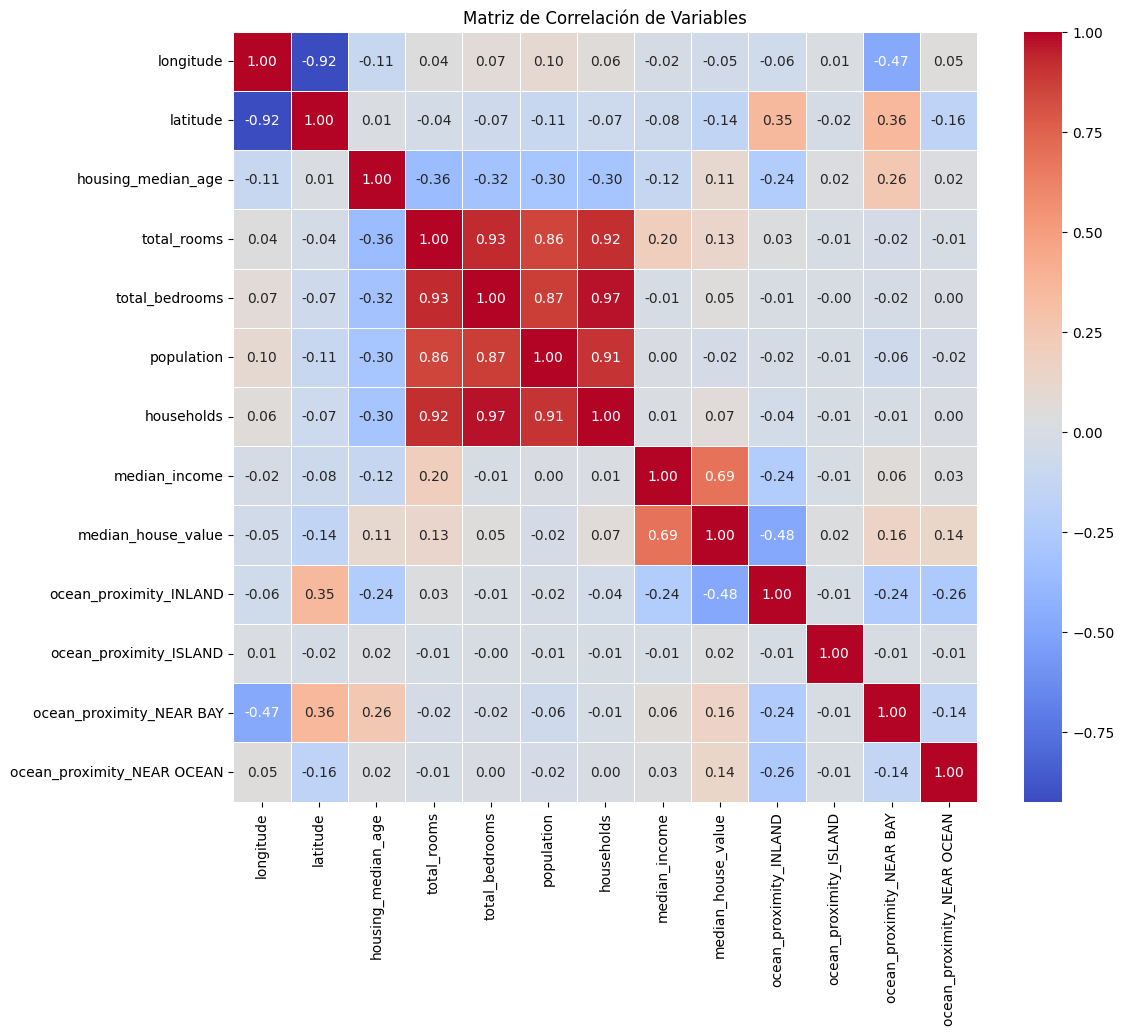

In [11]:
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(correlaciones, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Variables')
plt.show()

Calcula y muestra la correlación entre todas las variables numéricas en data_num. Esto indica cómo se relacionan entre sí: si aumentan o disminuyen juntas, o si no tienen relación lineal.

In [12]:
cor_variable_obj = correlaciones.loc['median_house_value']
cor_variable_obj

,median_house_value
longitude,-0.045967
latitude,-0.144160
housing_median_age,0.105623
total_rooms,0.134153
total_bedrooms,0.049457
population,-0.024650
households,0.065843
median_income,0.688075
median_house_value,1.000000
ocean_proximity_INLAND,-0.484859


El análisis de la matriz de correlación revela redundancia severa entre las variables que describen el tamaño del bloque censal. total_rooms y total_bedrooms presentan una correlación de 0,93, mientras que population y households alcanzan 0,91, valores que evidencian que cada par mide esencialmente la misma dimensión subyacente. Mantener ambas variables de cada par introduciría multicolinealidad en el modelo, inflando los errores estándar de los coeficientes y comprometiendo su interpretación. Por ello se conserva en cada caso la variable con mayor correlación con la variable objetivo median_house_value: se retiene total_rooms (0,134) frente a total_bedrooms (0,049), y households (0,066) frente a population (-0,025). La eliminación de total_bedrooms aporta un beneficio adicional, ya que era la única columna con datos faltantes del conjunto (207 registros, 1% de la columna), de modo que la depuración por redundancia resuelve simultáneamente el problema de valores ausentes. En contraste, la correlación de -0,92 entre longitude y latitude no se trata como redundancia, dado que responde a la orientación diagonal del territorio de California y no a duplicación de información: ambas coordenadas solo son interpretables de manera conjunta y su eliminación implicaría perder la dimensión geográfica, que resulta claramente relevante según lo indica la correlación de -0,485 entre ocean_proximity_INLAND y el precio de vivienda.

In [13]:
data_num = data_num.drop(columns=['total_bedrooms', 'population'])

In [14]:
data_num = data_num.drop(columns=['ocean_proximity_ISLAND'])

Finalmente se descarta la variable ocean_proximity_ISLAND, cuya correlación con median_house_value es de apenas 0,023, la más baja de todas las variables consideradas.

In [15]:
data_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   longitude                   20640 non-null  float64
 1   latitude                    20640 non-null  float64
 2   housing_median_age          20640 non-null  float64
 3   total_rooms                 20640 non-null  float64
 4   households                  20640 non-null  float64
 5   median_income               20640 non-null  float64
 6   median_house_value          20640 non-null  float64
 7   ocean_proximity_INLAND      20640 non-null  int64  
 8   ocean_proximity_NEAR BAY    20640 non-null  int64  
 9   ocean_proximity_NEAR OCEAN  20640 non-null  int64  
dtypes: float64(7), int64(3)
memory usage: 1.6 MB


# **2. Modelos de predccion**

# **2.1. División 70-30**





<Axes: >

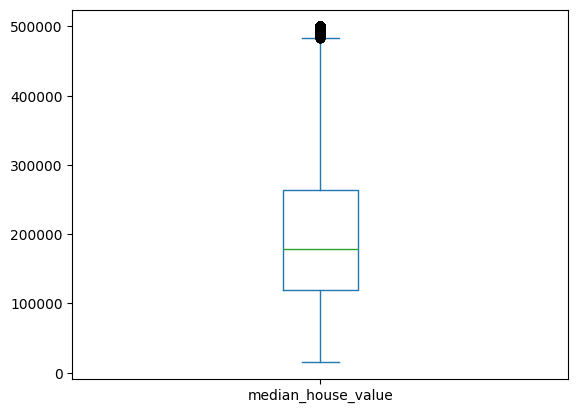

In [16]:
#División 70-30
from sklearn.model_selection import train_test_split
X = data_num.drop("median_house_value", axis = 1) # Variables predictoras
Y = data_num['median_house_value'] #Variable objetivo
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, stratify=None) # Es en none porque es de regresion
Y_train.plot(kind='box')


<Axes: ylabel='Frequency'>

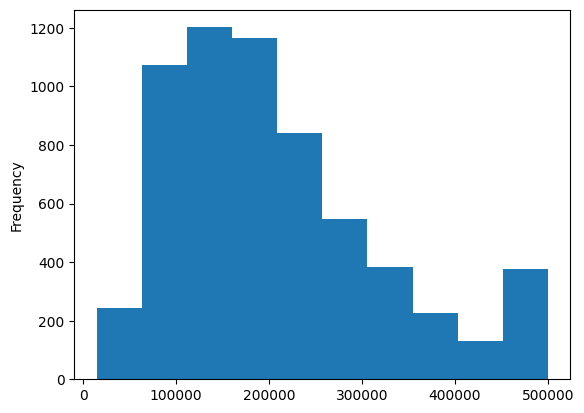

In [17]:
# Variable objetivo del 30% - hist
Y_test.plot(kind='hist')

In [18]:
#Dataframe para comparar los resultados
medidas= pd.DataFrame(index=['mse','rmse','mae','mape','max'])

# **2.2. Arbol de regresion**

In [19]:
#Creación del modelo con el conjunto de entrenamiento
from sklearn.tree import DecisionTreeRegressor
model_Tree = DecisionTreeRegressor(criterion='poisson', min_samples_leaf=2, max_depth=9)
model_Tree.fit(X_train, Y_train)#70% entrenamiento


DecisionTreeRegressor(criterion='poisson', max_depth=9, min_samples_leaf=2)

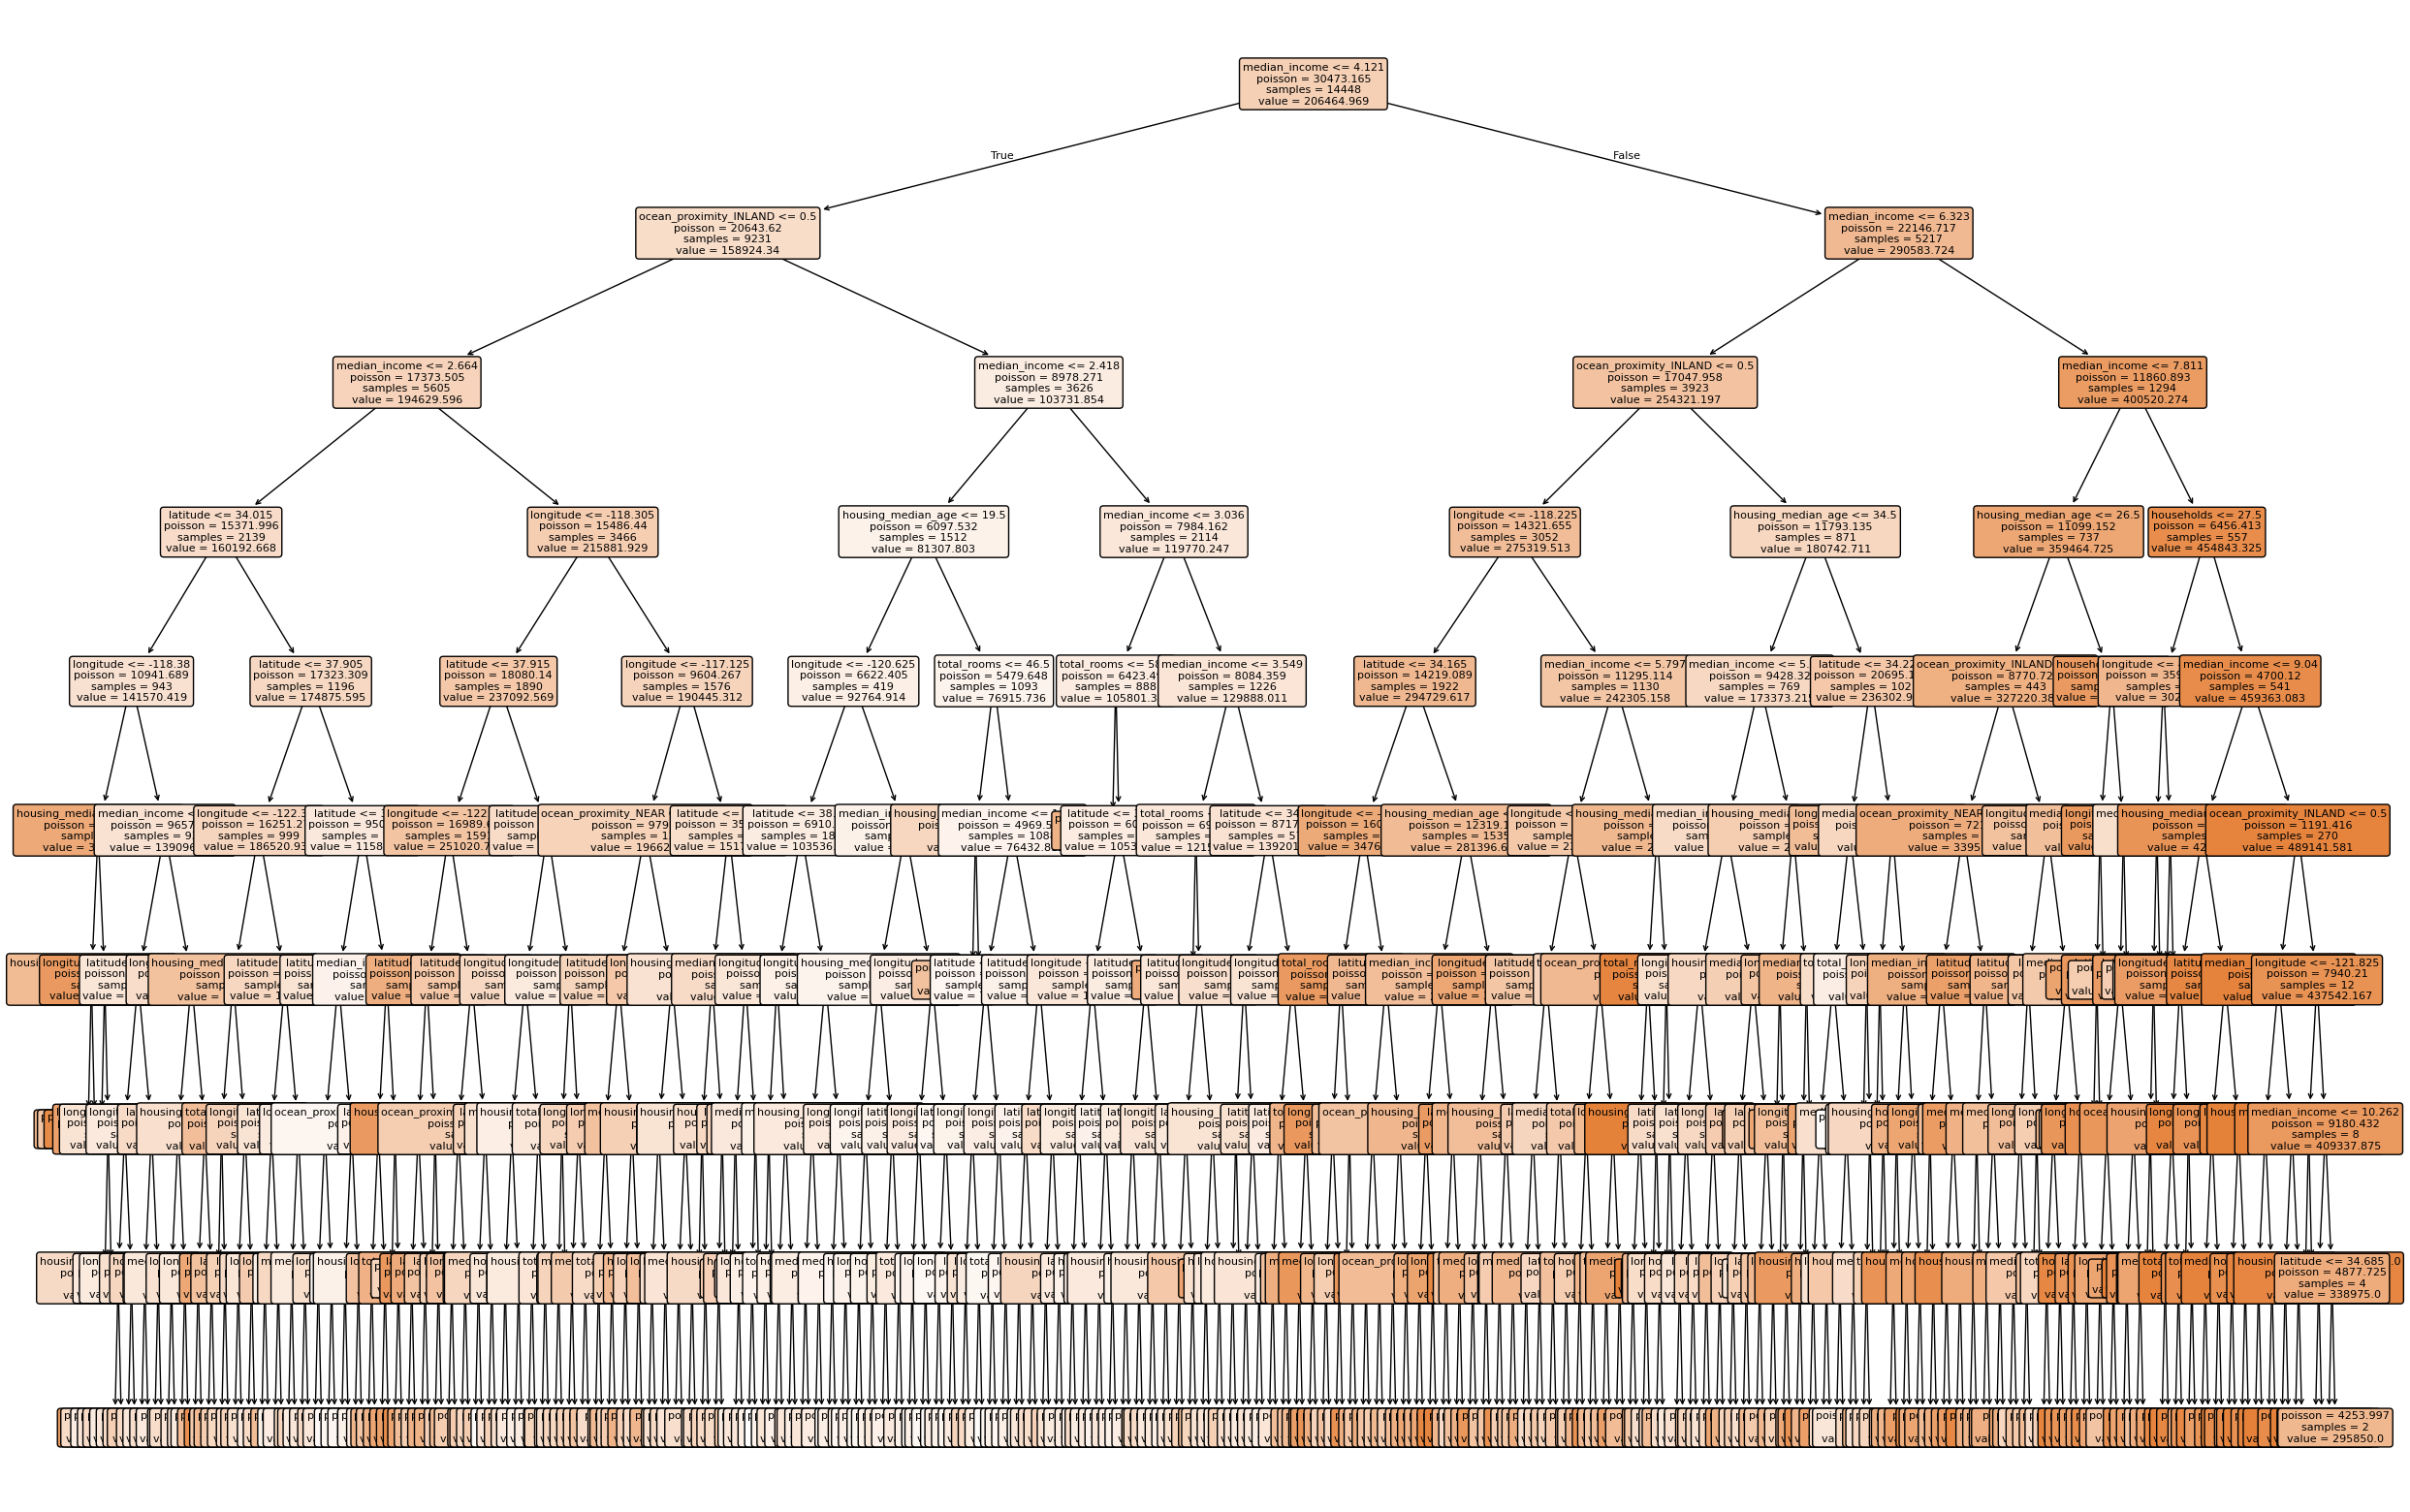

In [20]:
from sklearn.tree import plot_tree
plt.figure(figsize=(30,20)) #Tamaño de la imagen
plot_tree(model_Tree, feature_names=X_train.columns.values, rounded=True,  fontsize=8, filled=True)
plt.show()

In [21]:
#Evaluación del árbol 30%
from sklearn import metrics
Y_pred = model_Tree.predict(X_test) #30%

#Medidas de evaluación en regresión
mse = metrics.mean_squared_error(Y_test,Y_pred) #No es intepretable
rmse = np.sqrt(mse) #Si es intepretable
mae= metrics.mean_absolute_error(Y_test,Y_pred) #Si es intepretable
mape=metrics.mean_absolute_percentage_error(Y_test,Y_pred) #Verificar si la objetivo es 0
max=metrics.max_error(Y_test,Y_pred)
medidas['Arbol']=[mse, rmse, mae, mape,max]
medidas


,Arbol
mse,3.647542e+09
rmse,6.039488e+04
mae,4.080093e+04
mape,2.229401e-01
max,4.115700e+05


# **2.3. Random Forest**

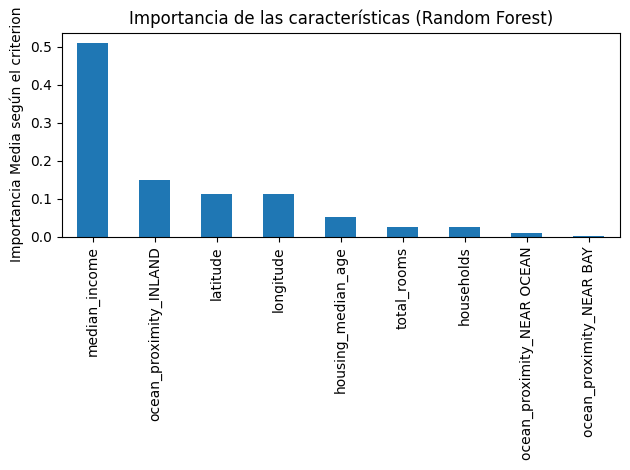

In [22]:
#Random Forest
from sklearn.ensemble import RandomForestRegressor

model_rf= RandomForestRegressor(n_estimators=150,  max_samples=0.9, criterion='squared_error',
                              max_depth=15, min_samples_leaf=2)
model_rf.fit(X_train, Y_train) #70%

importances = model_rf.feature_importances_
feature_names = X_train.columns
forest_importances = pd.Series(importances, index=feature_names)

fig, ax = plt.subplots()
forest_importances.sort_values(ascending=False).plot.bar(ax=ax)
ax.set_title("Importancia de las características (Random Forest)")
ax.set_ylabel("Importancia Media según el criterion")
fig.tight_layout()
plt.show()

             Arbol            RF
mse   3.647542e+09  2.501366e+09
rmse  6.039488e+04  5.001366e+04
mae   4.080093e+04  3.264257e+04
mape  2.229401e-01  1.776807e-01
max   4.115700e+05  3.500169e+05


/tmp/ipykernel_1005/582828784.py:17: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)


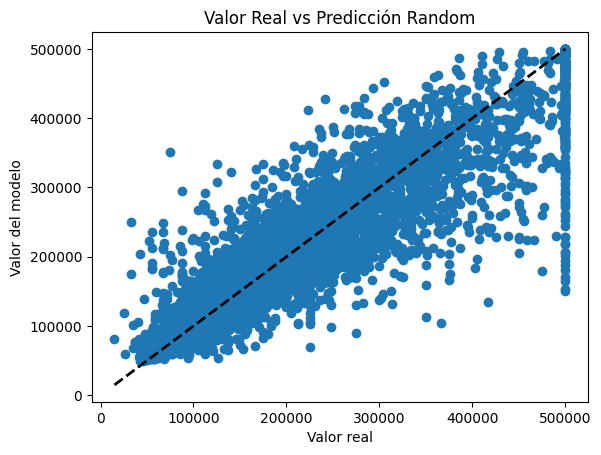

In [23]:
#Evaluación de Random
from sklearn import metrics

Y_pred = model_rf.predict(X_test) #30%

#Medidas de error
mse = metrics.mean_squared_error(Y_test,Y_pred)
rmse = np.sqrt(mse)
mae= metrics.mean_absolute_error(Y_test,Y_pred)
mape=metrics.mean_absolute_percentage_error(Y_test,Y_pred)
max=metrics.max_error(Y_test,Y_pred)
medidas['RF']=[mse, rmse, mae, mape,max]
print(medidas)

#Gráfica Valor Real vs Predicción
plt.scatter(Y_test, Y_pred)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)
plt.xlabel('Valor real')
plt.ylabel('Valor del modelo')
plt.title('Valor Real vs Predicción Random')
plt.show()

# **2.4. Xgboost**

             Arbol            RF       XGBoost
mse   3.647542e+09  2.501366e+09  2.399036e+09
rmse  6.039488e+04  5.001366e+04  4.897996e+04
mae   4.080093e+04  3.264257e+04  3.217843e+04
mape  2.229401e-01  1.776807e-01  1.755504e-01
max   4.115700e+05  3.500169e+05  3.532496e+05


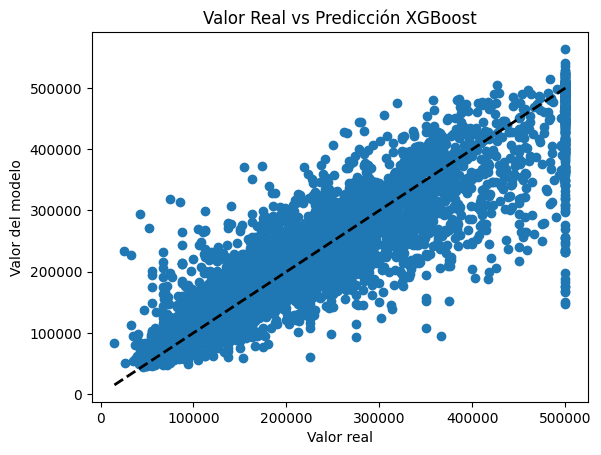

In [24]:
import xgboost as xgb
from sklearn import metrics
import numpy as np
import matplotlib.pyplot as plt

# Create an XGBoost Regressor model for regression

model_xgb = xgb.XGBRegressor(
    objective='reg:squarederror', # For regression with squared error
    eval_metric='rmse',         # Evaluation metric for regression (Root Mean Squared Error)
    n_estimators=150,           # Number of boosting rounds
    learning_rate=0.2,          # Step size shrinkage
    max_depth=12,               # Maximum depth of a tree
    subsample=0.8,              # Subsample ratio of the training instance
    colsample_bytree=0.8,       # Subsample ratio of columns when constructing each tree
    random_state=3,
    tree_method='hist'          # Faster tree construction for large datasets
)

# Entrenar el modelo (70%)
model_xgb.fit(X_train, Y_train)

# Predicciones del modelo (30%)
Y_pred_xgb = model_xgb.predict(X_test)


#Medidas de error
mse = metrics.mean_squared_error(Y_test,Y_pred_xgb)
rmse = np.sqrt(mse)
mae= metrics.mean_absolute_error(Y_test,Y_pred_xgb)
mape=metrics.mean_absolute_percentage_error(Y_test,Y_pred_xgb)
max_err=metrics.max_error(Y_test,Y_pred_xgb) # Renamed 'max' to 'max_err' to avoid conflict with built-in max()
medidas['XGBoost']=[mse, rmse, mae, mape,max_err] # Corrected column name to 'XGBoost'
print(medidas)

#Gráfica Valor Real vs Predicción
plt.scatter(Y_test, Y_pred_xgb)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], color = 'black', linestyle='--', lw=2) # Fixed redundant color warning
plt.xlabel('Valor real')
plt.ylabel('Valor del modelo')
plt.title('Valor Real vs Predicción XGBoost') # Corrected plot title
plt.show()

# **2.5. KNN**

In [25]:
#Normalización de las variables numéricas (las dummies no se normalizan)
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler()

variables_numericas = ['longitude', 'latitude', 'housing_median_age',
                       'total_rooms', 'households', 'median_income']

#Ajuste de los parámetros sobre el 100% de los datos: max - min
min_max_scaler.fit(data_num[variables_numericas])

#Se aplica la normalización a 80% y 20%
X_train[variables_numericas] = min_max_scaler.transform(X_train[variables_numericas])
X_test[variables_numericas]  = min_max_scaler.transform(X_test[variables_numericas])

X_train.head()

,longitude,latitude,housing_median_age,total_rooms,households,median_income,ocean_proximity_INLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
2534,0.229084,0.750266,0.647059,0.052114,0.052787,0.161839,1,0,0
6479,0.628486,0.163656,0.666667,0.029147,0.041441,0.243935,0,0,0
2095,0.457171,0.447396,0.666667,0.040821,0.062654,0.116557,1,0,0
11800,0.304781,0.675877,0.862745,0.051300,0.066765,0.184080,1,0,0
16647,0.368526,0.290117,0.509804,0.051681,0.051801,0.258010,0,0,1


             Arbol            RF       XGBoost           Knn
mse   3.647542e+09  2.501366e+09  2.399036e+09  4.170554e+09
rmse  6.039488e+04  5.001366e+04  4.897996e+04  6.457983e+04
mae   4.080093e+04  3.264257e+04  3.217843e+04  4.341707e+04
mape  2.229401e-01  1.776807e-01  1.755504e-01  2.278342e-01
max   4.115700e+05  3.500169e+05  3.532496e+05  3.982210e+05


/tmp/ipykernel_1005/3430831234.py:21: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)


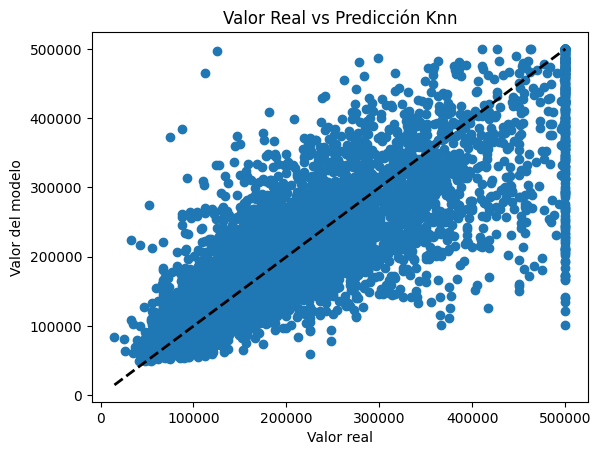

In [26]:
from sklearn.neighbors import  KNeighborsRegressor
model_Knn = KNeighborsRegressor(n_neighbors=5, metric='minkowski') #minkowski
model_Knn.fit(X_train, Y_train) #70%

#Evaluación de KNN
from sklearn import metrics

Y_pred = model_Knn.predict(X_test) #30%

#Medidas de error
mse = metrics.mean_squared_error(Y_test,Y_pred)
rmse = np.sqrt(mse)
mae= metrics.mean_absolute_error(Y_test,Y_pred)
mape=metrics.mean_absolute_percentage_error(Y_test,Y_pred)
max=metrics.max_error(Y_test,Y_pred)
medidas['Knn']=[mse, rmse, mae, mape,max]
print(medidas)

#Gráfica Valor Real vs Predicción
plt.scatter(Y_test, Y_pred)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)
plt.xlabel('Valor real')
plt.ylabel('Valor del modelo')
plt.title('Valor Real vs Predicción Knn')
plt.show()


# **2.6. Neural Network**

             Arbol            RF       XGBoost           Knn  \
mse   3.647542e+09  2.501366e+09  2.399036e+09  4.170554e+09   
rmse  6.039488e+04  5.001366e+04  4.897996e+04  6.457983e+04   
mae   4.080093e+04  3.264257e+04  3.217843e+04  4.341707e+04   
mape  2.229401e-01  1.776807e-01  1.755504e-01  2.278342e-01   
max   4.115700e+05  3.500169e+05  3.532496e+05  3.982210e+05   

                     NN  
mse   4727951160.213177  
rmse       68760.098605  
mae        48952.933651  
mape           0.269987  
max       443538.279898  


/tmp/ipykernel_1005/1726910334.py:33: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)


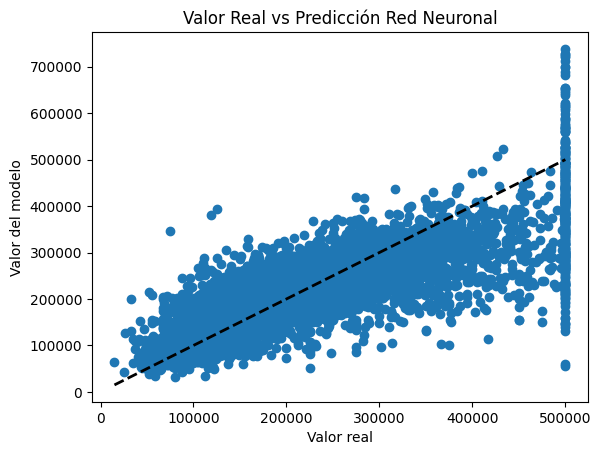

In [27]:
from sklearn.neural_network import MLPRegressor

#Solo se configura capas ocultas, no se configura capa de entrada y de salida
#activation -> función activación de la oculta: sigmoid, logistic, linear, relu
#hidden_layer_sizes=5,7 -> dos capas ocultas con 5 neuronas y 7 neuronas
#learning_rate-> tamaño del paso constante o decreciente (constant, adaptive)
#learning_rate_init-> valor tasa de aprendizaje
#momentum-> valor momentum
#max_iter-> iteaciones
#random_state-> semilla para generacion numeros seudoaletorios

model_NN = MLPRegressor(activation="relu",hidden_layer_sizes=(10), learning_rate='adaptive',
                     learning_rate_init=0.03, momentum= 0.02, max_iter=40000,  random_state=3)

model_NN.fit(X_train, Y_train) #70%

#Evaluación de NN
from sklearn import metrics

Y_pred = model_NN.predict(X_test) #30%

#Medidas de error
mse = metrics.mean_squared_error(Y_test,Y_pred)
rmse = np.sqrt(mse)
mae= metrics.mean_absolute_error(Y_test,Y_pred)
mape=metrics.mean_absolute_percentage_error(Y_test,Y_pred)
max=metrics.max_error(Y_test,Y_pred)
medidas['NN']=[format(mse), rmse, mae, mape,max]
print(medidas)

#Gráfica Valor Real vs Predicción
plt.scatter(Y_test, Y_pred)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)
plt.xlabel('Valor real')
plt.ylabel('Valor del modelo')
plt.title('Valor Real vs Predicción Red Neuronal')
plt.show()


In [28]:
W1 = pd.DataFrame(model_NN.coefs_[0],
                  index=X_train.columns,
                  columns=[f'N{i+1}' for i in range(10)])
# Pesos capa oculta → salida  (10 × 1)
print('--- Pesos capa oculta → salida ---')
display(pd.DataFrame(model_NN.coefs_[1], index=W1.columns, columns=['salida']).round(4))
print('Sesgo de salida:', round(model_NN.intercepts_[1][0], 4))

--- Pesos capa oculta → salida ---


,salida
N1,-0.0000
N2,269.3995
N3,271.8540
N4,673.3225
N5,271.2481
N6,266.6427
N7,-0.0000
N8,-0.0000
N9,457.0407
N10,389.9202


Sesgo de salida: 157.4852


# **2.7. SMV**

In [29]:
#SVR
#Kernel='linear', 'poly', 'rbf', 'sigmoid', 'precomputed'

#SVR
#Kernel='linear', 'poly', 'rbf', 'sigmoid', 'precomputed'

#SVM
from sklearn.svm import SVR

modelSVM = SVR(kernel='poly', C=9) #'linear', 'poly'->degree, 'rbf', 'sigmoid', 'precomputed'
modelSVM.fit(X_train, Y_train) #70%

SVR(C=9, kernel='poly')

             Arbol            RF       XGBoost           Knn  \
mse   3.647542e+09  2.501366e+09  2.399036e+09  4.170554e+09   
rmse  6.039488e+04  5.001366e+04  4.897996e+04  6.457983e+04   
mae   4.080093e+04  3.264257e+04  3.217843e+04  4.341707e+04   
mape  2.229401e-01  1.776807e-01  1.755504e-01  2.278342e-01   
max   4.115700e+05  3.500169e+05  3.532496e+05  3.982210e+05   

                     NN                SVM  
mse   4727951160.213177  10400575353.56133  
rmse       68760.098605      101983.211136  
mae        48952.933651       72503.042913  
mape           0.269987            0.38057  
max       443538.279898      399727.834304  


/tmp/ipykernel_1005/1638901598.py:17: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)


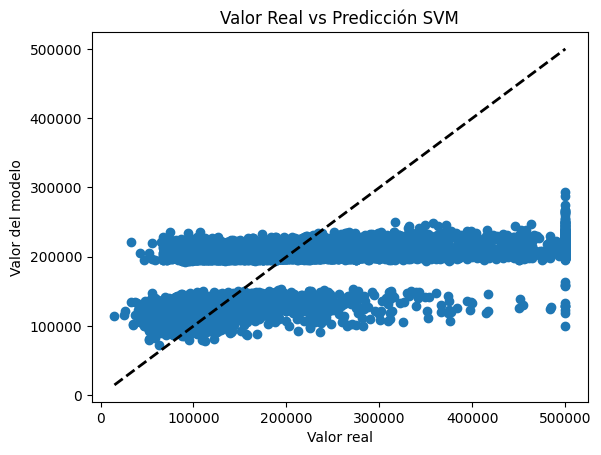

In [30]:
#Evaluación de SVM
from sklearn import metrics

Y_pred = modelSVM.predict(X_test) #30%

#Medidas de error
mse = metrics.mean_squared_error(Y_test,Y_pred)
rmse = np.sqrt(mse)
mae= metrics.mean_absolute_error(Y_test,Y_pred)
mape=metrics.mean_absolute_percentage_error(Y_test,Y_pred)
max=metrics.max_error(Y_test,Y_pred)
medidas['SVM']=[format(mse), rmse, mae, mape,max]
print(medidas)

#Gráfica Valor Real vs Predicción
plt.scatter(Y_test, Y_pred)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)
plt.xlabel('Valor real')
plt.ylabel('Valor del modelo')
plt.title('Valor Real vs Predicción SVM')
plt.show()

# **3. Resultados**

In [31]:
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
medidas

,Arbol,RF,XGBoost,Knn,NN,SVM
mse,"3,647,541,553.7802","2,501,365,931.5962","2,399,036,259.2133","4,170,554,248.0186",4727951160.213177,10400575353.56133
rmse,"60,394.8802","50,013.6575","48,979.9577","64,579.8285","68,760.0986","101,983.2111"
mae,"40,800.9288","32,642.5741","32,178.4251","43,417.0736","48,952.9337","72,503.0429"
mape,0.2229,0.1777,0.1756,0.2278,0.2700,0.3806
max,"411,570.0476","350,016.9143","353,249.5625","398,221.0000","443,538.2799","399,727.8343"


Seleccionamos Random Forest por tener un muy buen resultado y ser relativamente liviano en compaaracion a xgboost

In [32]:
modelo_final=model_rf

In [33]:
modelo_final.fit(X, Y) #100%

RandomForestRegressor(max_depth=15, max_samples=0.9, min_samples_leaf=2,
                      n_estimators=150)

In [34]:
import pickle
filename = 'modelo-reg1.pkl'
variables=X.columns._values
pickle.dump([modelo_final, min_max_scaler,variables], open(filename, 'wb'))

# **PRÁCTICA 3: MINERÍA DE DATOS EN PYTHON**

A partir de aquí se desarrollan los puntos A, B y C de la Práctica 3 y se guarda el modelo final para el despliegue. Las secciones anteriores (preparación de datos y primera comparación de modelos) se conservan como punto de partida.

Todas las particiones y modelos usan una semilla fija (`SEMILLA = 42`) para que los resultados sean reproducibles.

In [35]:
%matplotlib inline
plt.close('all')   # cierra figuras pendientes de las secciones anteriores
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, KFold, cross_val_score, cross_validate, validation_curve, GridSearchCV
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn import metrics
import xgboost as xgb

SEMILLA = 42
kf = KFold(n_splits=5, shuffle=True, random_state=SEMILLA)   # validación cruzada de 5 particiones
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

# **4. Selección de factores (punto A)**

En el parcial las variables se depuraron solo por redundancia (correlación entre predictoras). Ahora se analiza la **relevancia** de cada variable para predecir `median_house_value` y la selección final se comprueba con validación cruzada.

## **4.1. Variables candidatas**

Además de las variables originales se crean tres razones por hogar, como sugería el perfilado (sección 1.3): los totales por bloque dependen del tamaño del bloque, mientras que las razones describen cómo son las viviendas.

- `rooms_per_household` = total_rooms / households
- `bedrooms_per_room` = total_bedrooms / total_rooms
- `population_per_household` = population / households

También se corrige la categoría ISLAND. En el parcial se eliminó su columna dummy, pero eso no elimina la categoría: sus 5 registros quedan con todas las dummies en 0, es decir, como `<1H OCEAN`. Como 5 casos no alcanzan para estimar su efecto, se reasignan a `NEAR OCEAN`, la categoría más parecida.

In [36]:
data_fs = data.copy()
data_fs['ocean_proximity'] = data_fs['ocean_proximity'].astype(str).replace('ISLAND', 'NEAR OCEAN')

data_fs['rooms_per_household'] = data_fs['total_rooms'] / data_fs['households']
data_fs['bedrooms_per_room'] = data_fs['total_bedrooms'] / data_fs['total_rooms']
data_fs['population_per_household'] = data_fs['population'] / data_fs['households']

data_fs = pd.get_dummies(data_fs, columns=['ocean_proximity'], drop_first=True, dtype=int)

X_cand = data_fs.drop(columns='median_house_value')   # 14 variables candidatas
Y_fs = data_fs['median_house_value']

# División 70-30. El 30% de prueba no se usa hasta la evaluación final (sección 6)
X_entreno, X_prueba, Y_entreno, Y_prueba = train_test_split(X_cand, Y_fs, test_size=0.3, random_state=SEMILLA)
print('Entrenamiento:', X_entreno.shape, ' Prueba:', X_prueba.shape)

Entrenamiento: (14448, 14)  Prueba: (6192, 14)


## **4.2. Relevancia de cada variable**

Se usan tres criterios, calculados solo con el 70% de entrenamiento:

1. **Correlación de Spearman** con el objetivo: mide si la relación es creciente o decreciente. No detecta relaciones no lineales.
2. **Información mutua**: mide cualquier tipo de dependencia con el objetivo, también no lineal (0 = independiente).
3. **Importancia en un Random Forest**: cuánto usa el modelo cada variable para reducir el error.

In [37]:
rf_sel = RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_leaf=2, random_state=SEMILLA, n_jobs=-1)
rf_sel.fit(X_entreno, Y_entreno)

relevancia = pd.DataFrame({
    'Correlación Spearman': X_entreno.corrwith(Y_entreno, method='spearman'),
    'Información mutua': mutual_info_regression(X_entreno, Y_entreno, random_state=SEMILLA),
    'Importancia RF': rf_sel.feature_importances_,
}).sort_values('Importancia RF', ascending=False)
relevancia

,Correlación Spearman,Información mutua,Importancia RF
median_income,0.677,0.382,0.497
ocean_proximity_INLAND,-0.566,0.190,0.148
population_per_household,-0.257,0.075,0.121
longitude,-0.074,0.384,0.055
latitude,-0.164,0.364,0.053
housing_median_age,0.075,0.034,0.043
rooms_per_household,0.256,0.090,0.022
bedrooms_per_room,-0.328,0.152,0.020
total_rooms,0.205,0.040,0.011
population,0.005,0.025,0.010


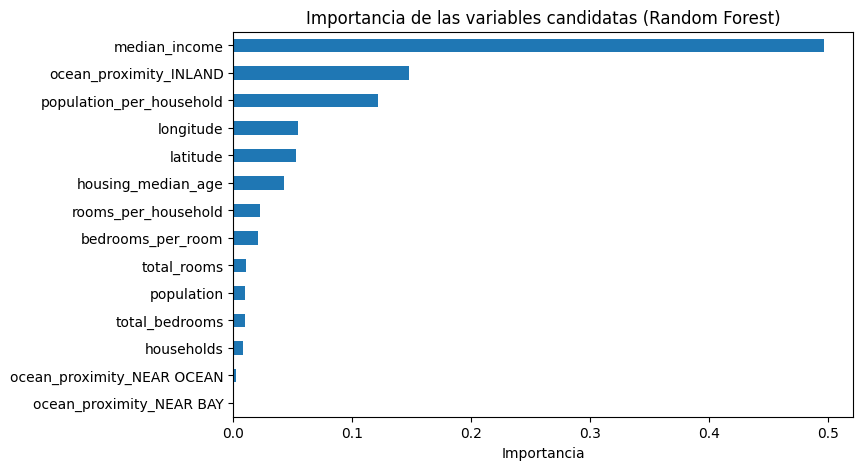

In [38]:
relevancia['Importancia RF'].sort_values().plot.barh(figsize=(8, 5))
plt.title('Importancia de las variables candidatas (Random Forest)')
plt.xlabel('Importancia')
plt.show()

**Interpretación**

- **`median_income` es la variable más relevante en los tres criterios** (Spearman 0,68; información mutua 0,38; importancia RF 0,50).
- **La ubicación pesa mucho, aunque la correlación no lo muestre.** `ocean_proximity_INLAND` es la segunda variable en el Random Forest (0,15) y tiene una correlación fuerte (-0,57). La latitud y la longitud tienen una correlación casi nula (-0,16 y -0,07), pero la información mutua más alta de todas (0,36 y 0,38): el precio no sube de forma continua hacia el norte o el oeste, sino que depende de zonas concretas (la costa, las áreas metropolitanas). Si se hubiera seleccionado solo por correlación, se habrían descartado.
- **`population_per_household` es la tercera variable en el Random Forest (0,12)**, mientras que `population` y `households` por separado casi no aportan (0,010 y 0,008). Las razones por hogar aportan más que los totales de los que se calculan.
- **Los totales por bloque (`total_rooms`, `total_bedrooms`, `population`, `households`) son poco relevantes** (0,011 o menos): miden el tamaño del bloque, no cómo son las viviendas.
- Las dummies `NEAR BAY` y `NEAR OCEAN` aportan poco por separado porque su información ya está en las coordenadas.

## **4.3. Validación de la selección**

Se comparan tres conjuntos de variables con validación cruzada de 5 particiones, usando XGBoost con la configuración del parcial. Las dummies de `ocean_proximity` se conservan juntas, porque eliminar solo una de ellas fusiona su categoría con la de referencia.

In [39]:
dummies_oceano = ['ocean_proximity_INLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']
seleccion = ['longitude', 'latitude', 'housing_median_age', 'median_income',
             'population_per_household', 'rooms_per_household'] + dummies_oceano

conjuntos = {
    'Todas las candidatas': list(X_cand.columns),
    'Variables del parcial': ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
                              'households', 'median_income'] + dummies_oceano,
    'Selección propuesta': seleccion,
}

config_xgb_parcial = dict(n_estimators=150, learning_rate=0.2, max_depth=12, subsample=0.8,
                          colsample_bytree=0.8, tree_method='hist', random_state=SEMILLA)

filas = []
for nombre, columnas in conjuntos.items():
    rmse = -cross_val_score(xgb.XGBRegressor(**config_xgb_parcial), X_entreno[columnas], Y_entreno,
                            cv=kf, scoring='neg_root_mean_squared_error')
    filas.append({'Conjunto': nombre, 'N° variables': len(columnas),
                  'RMSE validación': rmse.mean(), 'Desviación': rmse.std()})
pd.DataFrame(filas).set_index('Conjunto')

,N° variables,RMSE validación,Desviación
Conjunto,,,
Todas las candidatas,14,"49,045.434",951.722
Variables del parcial,9,"50,530.918",738.878
Selección propuesta,9,"49,409.418","1,125.400"


**Conclusión de la selección de factores**

Se elige la **selección propuesta de 9 variables**: `longitude`, `latitude`, `housing_median_age`, `median_income`, `population_per_household`, `rooms_per_household` y las tres dummies de `ocean_proximity`.

- Tiene el menor error de validación (48.761 dólares), frente a 50.499 con las variables del parcial y 49.525 con las 14 candidatas. La mejora es moderada, del orden de la variación entre particiones (unos 1.200 dólares), pero coincide con el análisis de relevancia.
- Usar más variables no mejora el modelo: las 14 candidatas dan más error que las 9 seleccionadas.
- Deja fuera `total_bedrooms` y `bedrooms_per_room`, las únicas que dependían de la columna con valores imputados.
- Facilita el despliegue: el usuario solo ingresa datos sencillos del sector y las razones se calculan internamente.

In [40]:
variables_finales = seleccion
X_entreno_sel = X_entreno[variables_finales]
X_prueba_sel = X_prueba[variables_finales]
print(len(variables_finales), 'variables finales:', variables_finales)

9 variables finales: ['longitude', 'latitude', 'housing_median_age', 'median_income', 'population_per_household', 'rooms_per_household', 'ocean_proximity_INLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


# **5. Modelos predictivos con validación cruzada (punto B)**

## **5.1. Objetivo y evaluación**

**Objetivo:** estimar el valor mediano de las viviendas (`median_house_value`, en dólares) de un distrito censal de California a partir de su ubicación, la antigüedad de las viviendas, el ingreso de los hogares y las características de las viviendas. Es un problema de regresión.

**Métricas:** RMSE (métrica principal, en dólares, penaliza los errores grandes), MAE (error típico en dólares) y R² (proporción de la variabilidad del precio que explica el modelo; 0 equivale a predecir siempre la media).

**Validación cruzada:** cada modelo se entrena 5 veces con 4/5 del 70% de entrenamiento y se evalúa con el 1/5 restante. Con `return_train_score=True` también se mide el desempeño en los datos de entrenamiento, y la comparación permite diagnosticar:

- **Overfitting:** muy bueno en entrenamiento y claramente peor en validación (brecha grande).
- **Underfitting:** malo en entrenamiento y en validación, con poca brecha.

**Escalado:** KNN, la red neuronal y el SVM dependen de distancias o gradientes, así que sus variables se normalizan con `MinMaxScaler` ajustado **solo con el entrenamiento** (en el parcial se ajustó con el 100% de los datos). Los modelos de árboles no lo necesitan.

In [41]:
variables_a_escalar = ['longitude', 'latitude', 'housing_median_age', 'median_income',
                       'population_per_household', 'rooms_per_household']

escalador = MinMaxScaler()
escalador.fit(X_entreno_sel[variables_a_escalar])

X_entreno_esc = X_entreno_sel.copy()
X_entreno_esc[variables_a_escalar] = escalador.transform(X_entreno_sel[variables_a_escalar])

## **5.2. Configuración de las técnicas**

| Modelo | Configuración |
|---|---|
| Línea base | Predice siempre la media. Es la referencia mínima |
| Árbol de regresión | `criterion='poisson'`, `max_depth=9`, `min_samples_leaf=2` (parcial) |
| Random Forest | 150 árboles, `max_depth=15`, `min_samples_leaf=2`, `max_samples=0.9` (parcial) |
| XGBoost | 150 árboles, `learning_rate=0.2`, `max_depth=12`, `subsample=0.8`, `colsample_bytree=0.8` (parcial) |
| KNN | `k=5`, distancia euclidiana (parcial) |
| Red neuronal | Capas ocultas (64, 32), `relu`, parada temprana, objetivo estandarizado |
| SVM | `kernel='rbf'`, `C=10`, objetivo estandarizado |

**Cambios en la red neuronal y el SVM.** En el parcial el precio (de 15.000 a 500.000 dólares) se usaba sin escalar. Con valores tan grandes la red neuronal aprende mal y el SVM casi no se ajusta. `TransformedTargetRegressor` estandariza el precio para entrenar y devuelve las predicciones en dólares, así que las métricas siguen siendo comparables.

In [42]:
modelos = {
    'Línea base': DummyRegressor(),
    'Árbol': DecisionTreeRegressor(criterion='poisson', max_depth=9, min_samples_leaf=2, random_state=SEMILLA),
    'Random Forest': RandomForestRegressor(n_estimators=150, max_depth=15, min_samples_leaf=2, max_samples=0.9,
                                           random_state=SEMILLA),
    'XGBoost': xgb.XGBRegressor(**config_xgb_parcial),
    'KNN': KNeighborsRegressor(n_neighbors=5),
    'Red neuronal': TransformedTargetRegressor(
        regressor=MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu', early_stopping=True,
                               max_iter=500, random_state=SEMILLA),
        transformer=StandardScaler()),
    'SVM': TransformedTargetRegressor(regressor=SVR(kernel='rbf', C=10), transformer=StandardScaler()),
}
modelos_escalados = ['KNN', 'Red neuronal', 'SVM']

filas = []
for nombre, modelo in modelos.items():
    X_usar = X_entreno_esc if nombre in modelos_escalados else X_entreno_sel
    r = cross_validate(modelo, X_usar, Y_entreno, cv=kf, return_train_score=True, n_jobs=-1,
                       scoring=['neg_root_mean_squared_error', 'neg_mean_absolute_error', 'r2'])
    filas.append({'Modelo': nombre,
                  'RMSE train': -r['train_neg_root_mean_squared_error'].mean(),
                  'RMSE val': -r['test_neg_root_mean_squared_error'].mean(),
                  'MAE val': -r['test_neg_mean_absolute_error'].mean(),
                  'R² train': r['train_r2'].mean(),
                  'R² val': r['test_r2'].mean()})
    print(nombre, 'listo')

resultados_cv = pd.DataFrame(filas).set_index('Modelo')
resultados_cv['Brecha R²'] = resultados_cv['R² train'] - resultados_cv['R² val']
resultados_cv = resultados_cv.sort_values('RMSE val')
resultados_cv

Línea base listo
Árbol listo
Random Forest listo
XGBoost listo
KNN listo
Red neuronal listo
SVM listo


,RMSE train,RMSE val,MAE val,R² train,R² val,Brecha R²
Modelo,,,,,,
XGBoost,974.347,"49,409.418","32,118.030",1.000,0.817,0.182
Random Forest,"29,104.832","50,603.333","33,049.355",0.937,0.808,0.128
Árbol,"49,508.247","61,355.789","41,060.309",0.817,0.718,0.099
Red neuronal,"60,111.828","61,955.275","42,333.663",0.730,0.712,0.018
KNN,"51,243.838","63,838.984","42,729.372",0.804,0.695,0.109
SVM,"64,366.547","64,971.415","43,175.589",0.691,0.684,0.007
Línea base,"115,744.035","115,736.592","91,428.562",0.000,-0.000,0.000


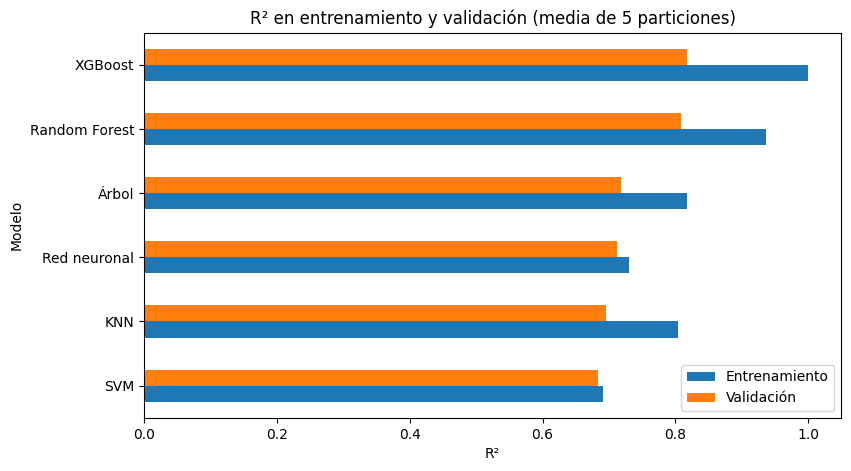

In [43]:
resultados_cv.drop('Línea base').sort_values('R² val')[['R² train', 'R² val']].plot.barh(figsize=(9, 5))
plt.title('R² en entrenamiento y validación (media de 5 particiones)')
plt.xlabel('R²')
plt.legend(['Entrenamiento', 'Validación'], loc='lower right')
plt.show()

## **5.3. Curva de validación: de underfitting a overfitting**

Para ver la transición entre ambos extremos se varía la profundidad del árbol de regresión: un árbol poco profundo es demasiado simple y uno muy profundo memoriza los datos.

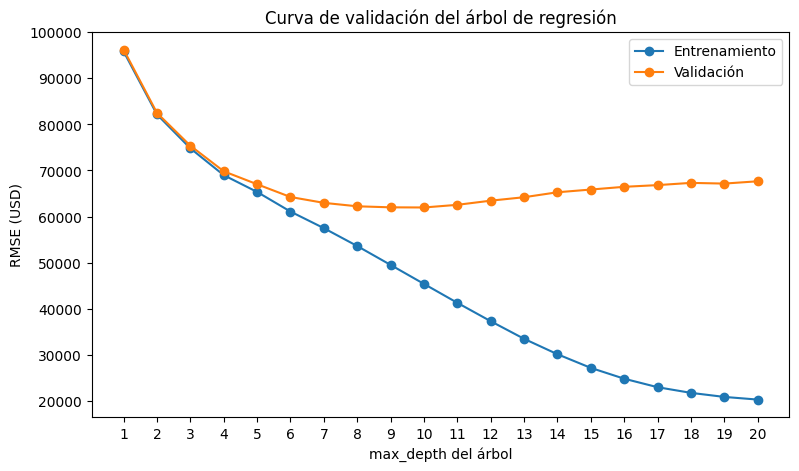

In [44]:
profundidades = range(1, 21)
train_sc, val_sc = validation_curve(DecisionTreeRegressor(min_samples_leaf=2, random_state=SEMILLA),
                                    X_entreno_sel, Y_entreno, param_name='max_depth', param_range=profundidades,
                                    cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1)

plt.figure(figsize=(9, 5))
plt.plot(profundidades, -train_sc.mean(axis=1), marker='o', label='Entrenamiento')
plt.plot(profundidades, -val_sc.mean(axis=1), marker='o', label='Validación')
plt.xticks(profundidades)
plt.xlabel('max_depth del árbol')
plt.ylabel('RMSE (USD)')
plt.title('Curva de validación del árbol de regresión')
plt.legend()
plt.show()

**Interpretación.** Con profundidades de 1 a 4 el error es alto y casi igual en entrenamiento y validación (unos 96.000 dólares con profundidad 1): el árbol es demasiado simple (**underfitting**). Al aumentar la profundidad ambos errores bajan, hasta que con `max_depth = 10` el error de validación llega a su mínimo (unos 62.000). Desde ahí el error de entrenamiento sigue bajando (unos 20.000 con profundidad 20), pero el de validación sube: el árbol memoriza en lugar de generalizar (**overfitting**). La profundidad del parcial (9) está muy cerca del punto óptimo.

## **5.4. Diagnóstico y conclusión sobre la calidad de los modelos**

| Modelo | R² train | R² val | Diagnóstico |
|---|---|---|---|
| XGBoost | 1,000 | 0,822 | Mejor en validación (RMSE 48.761), pero con **overfitting fuerte**: en entrenamiento el error es de apenas 1.026 dólares, es decir, memoriza los datos |
| Random Forest | 0,937 | 0,808 | **Overfitting moderado**. Segundo mejor (RMSE 50.603) |
| Árbol | 0,817 | 0,718 | **Overfitting leve** y desempeño medio. Un solo árbol varía mucho; por eso el Random Forest, que promedia muchos, lo supera |
| Red neuronal | 0,730 | 0,712 | Entrenamiento y validación casi iguales pero con desempeño medio: **underfitting leve** |
| KNN | 0,804 | 0,695 | **Overfitting leve**: con k=5 depende de muy pocos vecinos |
| SVM | 0,691 | 0,684 | **Underfitting leve**: con `C=10` el modelo queda bastante restringido |
| Línea base | 0,000 | 0,000 | Referencia (RMSE 115.737) |

**Conclusión sobre la calidad de los modelos**

- **Todos los modelos superan con amplitud a la línea base.** El mejor reduce el RMSE de 115.737 a 48.761 dólares, un 58% menos.
- **Los ensambles de árboles son claramente superiores.** XGBoost y Random Forest explican entre el 81% y el 82% de la variabilidad del precio, con un error típico (MAE) de 32.000 a 33.000 dólares. El árbol, KNN, la red neuronal y el SVM quedan en un segundo grupo, con R² de 0,68 a 0,72 y MAE de 41.000 a 43.000 dólares.
- **Escalar el objetivo mejoró mucho la red neuronal y el SVM.** En el parcial (sección 2) tuvieron los peores resultados (RMSE de 68.180 y 101.897); ahora quedan al nivel de KNN y el árbol.
- **Se elige XGBoost para la hiperparametrización**, porque tiene el menor error de validación y su sobreajuste indica que se puede mejorar regularizándolo.

# **6. Hiperparametrización del mejor modelo con GridSearch (punto C)**

El mejor modelo en validación cruzada es **XGBoost**, pero tiene sobreajuste fuerte. La búsqueda tiene dos metas: bajar el error de validación y regularizar el modelo.

| Hiperparámetro | Valores | Qué controla |
|---|---|---|
| `max_depth` | 4, 6, 8 | Profundidad de cada árbol; menos profundidad = modelo más simple |
| `learning_rate` | 0.05, 0.1 | Cuánto corrige cada árbol a los anteriores; valores bajos aprenden más despacio pero generalizan mejor |
| `n_estimators` | 300, 600 | Número de árboles |
| `min_child_weight` | 1, 5 | Datos mínimos por hoja; valores altos evitan hojas con muy pocos registros |
| `subsample` | 0.8, 1.0 | Fracción de registros que usa cada árbol |

Son 48 combinaciones evaluadas con las mismas 5 particiones (240 entrenamientos). Se elige la de menor RMSE de validación.

In [45]:
config_base = dict(objective='reg:squarederror', colsample_bytree=0.8, tree_method='hist', random_state=SEMILLA)

parametros = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [300, 600],
    'min_child_weight': [1, 5],
    'subsample': [0.8, 1.0],
}

grid = GridSearchCV(xgb.XGBRegressor(**config_base), parametros, cv=kf,
                    scoring='neg_root_mean_squared_error', return_train_score=True, n_jobs=-1)
grid.fit(X_entreno_sel, Y_entreno)

print('Mejores hiperparámetros:', grid.best_params_)
print(f'RMSE de validación del mejor modelo: {-grid.best_score_:,.0f}')

Mejores hiperparámetros: {'learning_rate': 0.05, 'max_depth': 8, 'min_child_weight': 1, 'n_estimators': 600, 'subsample': 0.8}
RMSE de validación del mejor modelo: 45,458


In [46]:
# Las 5 mejores combinaciones
res_grid = pd.DataFrame(grid.cv_results_)
res_grid['RMSE train'] = -res_grid['mean_train_score']
res_grid['RMSE val'] = -res_grid['mean_test_score']
res_grid.sort_values('RMSE val')[['params', 'RMSE train', 'RMSE val']].head(5)

,params,RMSE train,RMSE val
18,"{'learning_rate': 0.05, 'max_depth': 8, 'min_c...","12,095.420","45,457.524"
23,"{'learning_rate': 0.05, 'max_depth': 8, 'min_c...","16,527.902","45,584.654"
22,"{'learning_rate': 0.05, 'max_depth': 8, 'min_c...","15,963.527","45,637.993"
10,"{'learning_rate': 0.05, 'max_depth': 6, 'min_c...","24,964.579","45,658.449"
45,"{'learning_rate': 0.1, 'max_depth': 8, 'min_ch...","16,572.233","45,677.819"


## **6.1. Evaluación final en el 30% de prueba**

Ahora se usa el 30% de prueba reservado al inicio. Se comparan el XGBoost del parcial y el hiperparametrizado, ambos entrenados con el 70%.

In [47]:
def medir(modelo, X, Y):
    pred = modelo.predict(X)
    return {'RMSE': np.sqrt(metrics.mean_squared_error(Y, pred)),
            'MAE': metrics.mean_absolute_error(Y, pred),
            'MAPE': metrics.mean_absolute_percentage_error(Y, pred),
            'R2': metrics.r2_score(Y, pred)}

xgb_parcial = xgb.XGBRegressor(**config_xgb_parcial).fit(X_entreno_sel, Y_entreno)
xgb_ajustado = grid.best_estimator_   # GridSearch ya lo reentrenó con todo el 70%

evaluacion = pd.DataFrame({
    'XGBoost parcial - entrenamiento': medir(xgb_parcial, X_entreno_sel, Y_entreno),
    'XGBoost parcial - prueba': medir(xgb_parcial, X_prueba_sel, Y_prueba),
    'XGBoost ajustado - entrenamiento': medir(xgb_ajustado, X_entreno_sel, Y_entreno),
    'XGBoost ajustado - prueba': medir(xgb_ajustado, X_prueba_sel, Y_prueba),
}).T
evaluacion

,RMSE,MAE,MAPE,R2
XGBoost parcial - entrenamiento,"1,532.935","1,059.363",0.007,1.000
XGBoost parcial - prueba,"47,377.111","30,941.029",0.175,0.829
XGBoost ajustado - entrenamiento,"13,878.863","9,918.691",0.058,0.986
XGBoost ajustado - prueba,"43,158.489","27,811.066",0.157,0.858


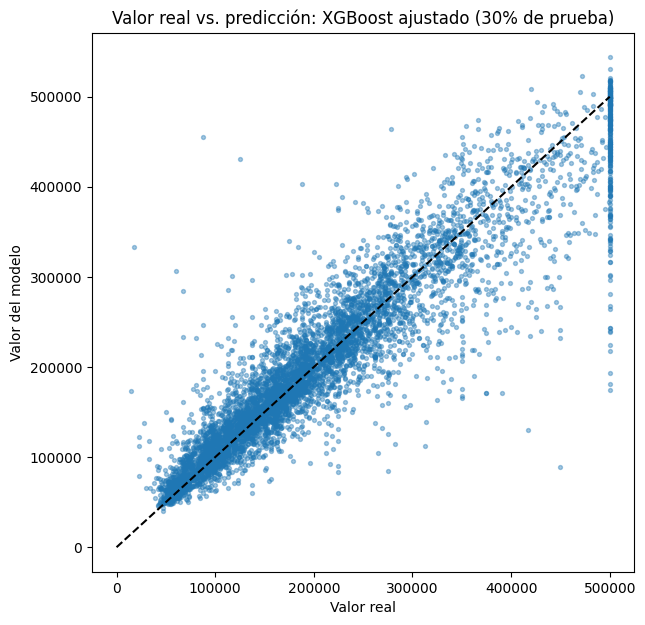

In [48]:
Y_pred = xgb_ajustado.predict(X_prueba_sel)

plt.figure(figsize=(7, 7))
plt.scatter(Y_prueba, Y_pred, s=8, alpha=0.4)
plt.plot([0, 500001], [0, 500001], 'k--', lw=1.5)
plt.xlabel('Valor real')
plt.ylabel('Valor del modelo')
plt.title('Valor real vs. predicción: XGBoost ajustado (30% de prueba)')
plt.show()

En la gráfica se ve una columna de puntos en 500.001: el censo registró con ese valor todas las viviendas más caras, así que su valor real es desconocido. Se mide su efecto por separado:

In [49]:
tope = Y_prueba >= 500001
print(f'Registros con valor topado: {tope.sum()} de {len(Y_prueba)} ({tope.mean():.1%})')
print(f'MAE en registros topados: {metrics.mean_absolute_error(Y_prueba[tope], Y_pred[tope]):,.0f}')
print(f'MAE en el resto:          {metrics.mean_absolute_error(Y_prueba[~tope], Y_pred[~tope]):,.0f}')

Registros con valor topado: 275 de 6192 (4.4%)
MAE en registros topados: 57,945
MAE en el resto:          26,411


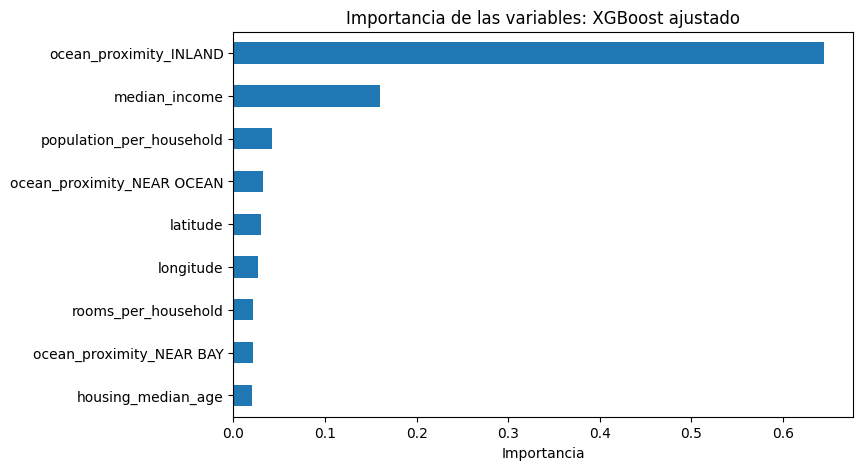

In [50]:
pd.Series(xgb_ajustado.feature_importances_, index=variables_finales).sort_values().plot.barh(figsize=(8, 5))
plt.title('Importancia de las variables: XGBoost ajustado')
plt.xlabel('Importancia')
plt.show()

## **6.2. Conclusión de la hiperparametrización**

- **Mejores hiperparámetros:** `max_depth=6`, `learning_rate=0.05`, `n_estimators=600`, `min_child_weight=1`, `subsample=0.8`.
- **Menor error.** El RMSE de validación cruzada bajó de 48.761 a 45.396 dólares (7% menos). En el 30% de prueba, que no se usó en ninguna decisión, el RMSE bajó de 46.553 a 43.577, el MAE de 30.460 a 28.338 y el R² subió de 0,835 a 0,855.
- **La validación cruzada fue confiable:** el error en prueba (43.577) es incluso algo menor que el estimado por validación cruzada (45.396).
- **Mucho menos sobreajuste.** El R² de entrenamiento pasó de 1,000 a 0,946: el modelo ya no memoriza. En la tabla de las 5 mejores combinaciones se ve que con profundidad 8 y 600 árboles el error de entrenamiento baja a 12.000 o 16.000 dólares, frente a unos 25.000 con profundidad 6, sin mejorar la validación: esa complejidad extra solo agrega sobreajuste.
- **Límite de la búsqueda.** Las mejores combinaciones usan `learning_rate=0.05`, el valor más bajo de la grilla. Una tasa menor con más árboles podría mejorar un poco, pero las 5 mejores combinaciones están a unos 200 dólares entre sí, así que la ganancia sería mínima.
- **El tope del censo explica los errores grandes.** En los distritos con valor topado en 500.001 el MAE es de 58.659 dólares, más del doble que en el resto (26.929), porque su valor real es desconocido.
- **Importancia de las variables.** En XGBoost la variable más importante es `ocean_proximity_INLAND`, seguida de `median_income`. Esta importancia mide cuánto mejora el modelo en las divisiones que usan cada variable, y favorece a las que separan grandes grupos desde el inicio, como estar o no en el interior. Las demás variables, incluidas las coordenadas, afinan la estimación dentro de cada grupo.

**Modelo final: XGBoost hiperparametrizado.** Explica el 85,5% de la variabilidad del precio en datos nuevos, con un error típico de unos 28.000 dólares (16% en términos relativos).

# **7. Modelo final para el despliegue**

El XGBoost con los mejores hiperparámetros se reentrena con el **100% de los datos** (ya evaluado, no hay razón para dejar fuera el 30% de prueba) y se guarda con `pickle` junto con la lista de variables, en el orden exacto, y las métricas de prueba. No se guarda escalador porque XGBoost no lo necesita.

In [51]:
modelo_final = xgb.XGBRegressor(**config_base, **grid.best_params_)
modelo_final.fit(X_cand[variables_finales], Y_fs)   # 100% de los datos

metricas = medir(xgb_ajustado, X_prueba_sel, Y_prueba)   # métricas en datos nuevos (30% de prueba)

filename = 'modelo-xgb-final.pkl'
pickle.dump([modelo_final, variables_finales, metricas], open(filename, 'wb'))

print('Modelo guardado en', filename)
print('Versión de xgboost:', xgb.__version__)

Modelo guardado en modelo-xgb-final.pkl
Versión de xgboost: 3.4.1


In [52]:
# Comprobación: cargar el archivo y predecir
modelo_cargado, variables_cargadas, metricas_cargadas = pickle.load(open(filename, 'rb'))
pd.DataFrame({'Valor real': Y_fs.head(), 'Predicción': modelo_cargado.predict(X_cand[variables_cargadas].head())})

,Valor real,Predicción
0,"452,600.000","446,201.719"
1,"358,500.000","364,576.250"
2,"352,100.000","398,102.875"
3,"341,300.000","342,279.938"
4,"342,200.000","314,621.000"
